In [ ]:
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 87.2 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
import scipy.sparse as sp
import networkx as nx

# Install deeprobust and its dependencies
!pip install deeprobust torch-geometric

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.4/219.4 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.7 MB/s eta 0:00:00


In [ ]:
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN

In [ ]:
pip show deeprobust

Name: deeprobust
Version: 0.2.11
Summary: A PyTorch library for adversarial robustness learning for image and graph data.
Home-page: https://github.com/DSE-MSU/DeepRobust
Author: MSU-DSE
Author-email: 
License: MIT
Location: /usr/local/lib/python3.12/dist-packages
Requires: gensim, matplotlib, networkx, numba, numpy, Pillow, scikit-image, scikit-learn, scipy, tensorboardX, texttable, torch, torchvision, tqdm
Required-by: 


In [ ]:
# 1. Define device (A100)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Install missing dependencies for torch_geometric and deeprobust
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{torch.__version__}.html

import numpy as np
import scipy.sparse as sp
from deeprobust.graph.targeted_attack import Nettack
from torch_geometric.utils import to_scipy_sparse_matrix

# Assuming 'data' is your torch_geometric.data.Data object
# Note: ensure 'data' is defined in your notebook before running this.
try:
    adj = to_scipy_sparse_matrix(data.edge_index)
    features = sp.csr_matrix(data.x.numpy())
    labels = data.y.numpy()

    # Initialize Nettack
    model = Nettack(adj, features, labels, device='cpu')
except NameError:
    print("Error: 'data' is not defined. Please load your graph data first.")

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 126.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 137.0 MB/s eta 0:00:00
Error: 'data' is not defined. Please load your graph data first.


In [ ]:
# ==========================================
# 1. GPU & LLM SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"System mapped to: {device}")

# Replace with your gated model if desired (e.g., meta-llama/Llama-2-7b-hf)
MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.1"

print(f"\n[INIT] Loading LLM ({MODEL_NAME}) in bfloat16...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
llm.eval()
print("[INIT] LLM Successfully Loaded.")

System mapped to: cuda

[INIT] Loading LLM (mistralai/Mistral-7B-Instruct-v0.1) in bfloat16...


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

[INIT] LLM Successfully Loaded.


In [ ]:
# ==========================================
# 2. DEFINING THE GOFA ARCHITECTURE & VALIDATOR
# ==========================================
import re
import torch
import torch.nn as nn

class GOFASimulator(nn.Module):
    def __init__(self, llm_model, tokenizer):
        super().__init__()
        self.llm = llm_model
        self.tokenizer = tokenizer

        self.dataset_meta = {
            'cora': {'desc': 'Computer Science Artificial Intelligence',
                     'classes': ["Case Based", "Genetic Algorithms", "Neural Networks", "Probabilistic Methods", "Reinforcement Learning", "Rule Learning", "Theory"]},
            'citeseer': {'desc': 'Computer Science & Information Retrieval',
                         'classes': ["Agents", "AI", "Database", "Information Retrieval", "Machine Learning", "HCI"]},
            'pubmed': {'desc': 'Medical Research on Diabetes',
                       'classes': ["Experimental Diabetes", "Type 1 Diabetes", "Type 2 Diabetes"]}
        }

    def generate_prompt(self, target_node, data, dataset_name):
        edges = data.edge_index
        neighbors = edges[1][edges[0] == target_node].tolist()
        meta = self.dataset_meta[dataset_name]

        prompt = f"System: You are an expert classifier for a {meta['desc']} citation graph.\n"
        prompt += f"Target Node {target_node} has {len(neighbors)} citations/connections to nodes: {neighbors}.\n"
        prompt += f"Categories: {', '.join(meta['classes'])}.\n"
        prompt += f"Question: What is the exact category for Node {target_node}? Respond with ONLY the exact category name.\n"
        prompt += "Answer: "
        return prompt

    def forward(self, target_node, data, dataset_name):
        prompt = self.generate_prompt(target_node, data, dataset_name)
        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.llm.device)

        with torch.no_grad():
            outputs = self.llm.generate(
                **inputs,
                max_new_tokens=15,
                temperature=0.1,
                do_sample=False,
                pad_token_id=self.tokenizer.eos_token_id
            )

        response = self.tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
        return response

def validate_prediction(prediction, true_class):
    """
    Validates LLM text output using flexible keyword/substring matching
    to handle cases where the LLM truncates output or adds filler.
    """
    pred_clean = prediction.lower().strip()
    true_clean = true_class.lower().strip()

    # 1. Exact or simple substring match
    if true_clean in pred_clean:
        return True

    # 2. Token-level partial match (e.g. "rule" matches "rule learning")
    pred_words = set(re.findall(r'\b\w+\b', pred_clean))
    true_words = set(re.findall(r'\b\w+\b', true_clean))

    # Check if any significant word (>= 3 chars) from the true class is in the prediction
    for tw in true_words:
        if len(tw) >= 3 and tw in pred_words:
            return True

    # 3. Truncated word match (e.g., "ret" for "retrieval")
    for pw in pred_words:
        if len(pw) >= 3 and any(pw in tw for tw in true_words):
            return True

    return False

In [ ]:
# ==========================================
# 3. ATTACK UTILITIES
# ==========================================
def run_structack(adj, target, n_pert=3):
    G = nx.from_scipy_sparse_array(adj)
    degrees = dict(G.degree())
    sorted_nodes = sorted(degrees, key=degrees.get)
    mod_adj = adj.tolil()
    added = 0
    target_neighbors = set(G.neighbors(target))

    for v in sorted_nodes:
        if added >= n_pert: break
        if v == target or mod_adj[target, v] == 1: continue

        v_neighbors = set(G.neighbors(v))
        if len(target_neighbors.intersection(v_neighbors)) == 0:
            mod_adj[target, v] = 1
            mod_adj[v, target] = 1
            added += 1

    return mod_adj.tocsr()

def to_pyg_data(scipy_adj, scipy_features, labels):
    coo = scipy_adj.tocoo()
    edge_index = torch.tensor(np.vstack((coo.row, coo.col)), dtype=torch.long)
    x = torch.tensor(scipy_features.todense(), dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

In [ ]:
# ==========================================
# 4. UPDATED METRICS PIPELINE (WITH PROGRESS LOGGING)
# ==========================================
def run_adversarial_pipeline():
    datasets = ['cora', 'citeseer']
    perturbation_budget = 3
    nodes_to_test = 20

    gfm = GOFASimulator(llm, tokenizer)

    for d_name in datasets:
        print(f"\n{'='*60}")
        print(f"=== EVALUATING DATASET: {d_name.upper()} ===")
        print(f"{'='*60}")

        try:
            data = Dataset(root='/tmp/', name=d_name, setting='nettack')
            adj, features, labels = data.adj, data.features, data.labels

            if not sp.issparse(adj): adj = sp.csr_matrix(adj)
            if not sp.issparse(features): features = sp.csr_matrix(features)

            print(f"[*] Training Surrogate GCN for {d_name}...")
            surrogate = GCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
            surrogate.fit(features, adj, labels, data.idx_train, data.idx_val)

            test_targets = data.idx_test[:nodes_to_test]
            metrics = {'total': 0, 'clean_correct': 0, 'nettack_correct': 0, 'structack_correct': 0, 'nettack_flips': 0, 'structack_flips': 0}

            print(f"[*] Processing {len(test_targets)} nodes...")

            for i, target_node in enumerate(test_targets):
                metrics['total'] += 1
                true_label_idx = labels[target_node]
                true_class_name = gfm.dataset_meta[d_name]['classes'][true_label_idx]

                # Clean Eval
                clean_gofa_data = to_pyg_data(adj, features, labels)
                clean_pred = gfm(target_node, clean_gofa_data, d_name)
                is_clean_correct = validate_prediction(clean_pred, true_class_name)

                if is_clean_correct: metrics['clean_correct'] += 1

                # Nettack
                ntk = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=True, device='cpu')
                ntk.attack(features, adj, labels, target_node, n_perturbations=perturbation_budget)
                ntk_data = to_pyg_data(ntk.modified_adj, ntk.modified_features, labels)
                ntk_pred = gfm(target_node, ntk_data, d_name)
                is_ntk_correct = validate_prediction(ntk_pred, true_class_name)

                if is_ntk_correct: metrics['nettack_correct'] += 1
                elif is_clean_correct: metrics['nettack_flips'] += 1

                # Structack
                s_adj = run_structack(adj, target_node, n_pert=perturbation_budget)
                s_data = to_pyg_data(s_adj, features, labels)
                s_pred = gfm(target_node, s_data, d_name)
                is_s_correct = validate_prediction(s_pred, true_class_name)

                if is_s_correct: metrics['structack_correct'] += 1
                elif is_clean_correct: metrics['structack_flips'] += 1

                print(f"Node {i+1}/{nodes_to_test} (ID {target_node}): True: {true_class_name} | Pred: {clean_pred} | Correct: {is_clean_correct}")

            # Final summary per dataset
            cc = max(metrics['clean_correct'], 1)
            print(f"\n[{d_name.upper()}] CA: {(metrics['clean_correct']/metrics['total'])*100:.2f}%")
            print(f"NETTACK AA: {(metrics['nettack_correct']/metrics['total'])*100:.2f}%, ASR: {(metrics['nettack_flips']/cc)*100:.2f}%")
            print(f"STRUCTACK AA: {(metrics['structack_correct']/metrics['total'])*100:.2f}%, ASR: {(metrics['structack_flips']/cc)*100:.2f}%")

        except Exception as e:
            print(f"[ERROR] Failed evaluating {d_name}: {e}")

if __name__ == '__main__':
    run_adversarial_pipeline()


=== EVALUATING DATASET: CORA ===
Loading cora dataset...
Selecting 1 largest connected components
[*] Training Surrogate GCN for cora...
[*] Processing 20 nodes...
##### Starting attack #####
##### Attack node with ID 2000 using structure and feature perturbations #####
##### Attacking the node directly #####
##### Performing 3 perturbations #####
##### ...1/3 perturbations ... #####
Edge perturbation: [2000 1595]
##### ...2/3 perturbations ... #####
Edge perturbation: [2000 1052]
##### ...3/3 perturbations ... #####
Edge perturbation: [2000 1702]
Node 1/20 (ID 2000): True: Reinforcement Learning | Pred: The exact category for Node 2000 is not provided | Correct: True
##### Starting attack #####
##### Attack node with ID 707 using structure and feature perturbations #####
##### Attacking the node directly #####
##### Performing 3 perturbations #####
##### ...1/3 perturbations ... #####
Edge perturbation: [ 707 2266]
##### ...2/3 perturbations ... #####
Edge perturbation: [ 707 2168]
#

Loading Cora and training surrogate...
Loading cora dataset...
Selecting 1 largest connected components
Attacking target node 1105 with budget 3...
##### Starting attack #####
##### Attack only using structure perturbations #####
##### Attacking the node directly #####
##### Performing 3 perturbations #####
##### ...1/3 perturbations ... #####
##### ...2/3 perturbations ... #####
##### ...3/3 perturbations ... #####
Adversarial edges added: [(1599, 1105), (np.int64(1105), 1531), (np.int64(1105), 1638)]


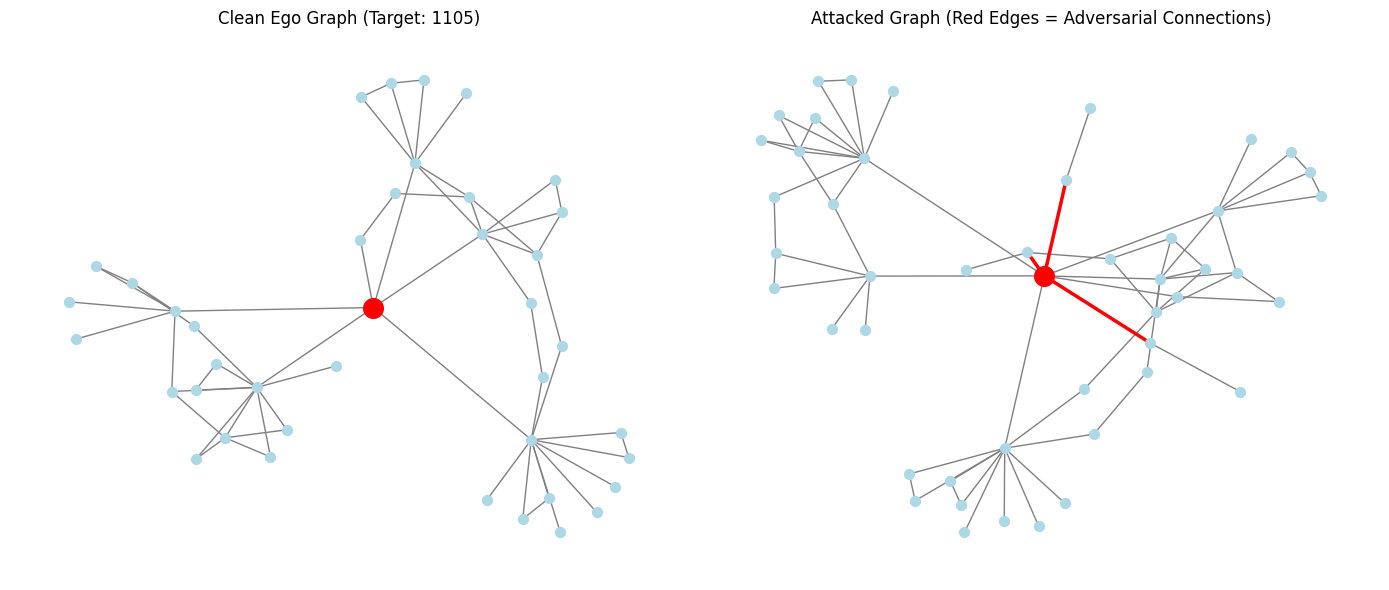

In [ ]:
# ==========================================
# 5. VISUALIZING THE ATTACK (EGO NETWORK)
# ==========================================
import networkx as nx
import matplotlib.pyplot as plt
import scipy.sparse as sp
from deeprobust.graph.data import Dataset
from deeprobust.graph.defense import GCN
from deeprobust.graph.targeted_attack import Nettack

# 1. Load Data & Train Surrogate
print("Loading Cora and training surrogate...")
data = Dataset(root='/tmp/', name='cora', setting='nettack')
adj, features, labels = data.adj, data.features, data.labels
if not sp.issparse(adj): adj = sp.csr_matrix(adj)
if not sp.issparse(features): features = sp.csr_matrix(features)

surrogate = GCN(nfeat=features.shape[1], nhid=16, nclass=labels.max().item() + 1, dropout=0.5, device='cpu')
surrogate.fit(features, adj, labels, data.idx_train, data.idx_val)

# 2. Pick a Target Node and Attack
target_node = data.idx_test[0]
perturbation_budget = 3

print(f"Attacking target node {target_node} with budget {perturbation_budget}...")
ntk = Nettack(surrogate, nnodes=adj.shape[0], attack_structure=True, attack_features=False, device='cpu')
ntk.attack(features, adj, labels, target_node, n_perturbations=perturbation_budget)
adj_attacked = ntk.modified_adj

# 3. Create NetworkX Graphs
G_clean = nx.from_scipy_sparse_array(adj)
G_attacked = nx.from_scipy_sparse_array(adj_attacked)

# Extract Ego Graphs (radius 2 for better context)
ego_clean = nx.ego_graph(G_clean, target_node, radius=2)
ego_attacked = nx.ego_graph(G_attacked, target_node, radius=2)

# Find the specific edges that were added by the attack
added_edges = [e for e in ego_attacked.edges() if not G_clean.has_edge(*e)]
print(f"Adversarial edges added: {added_edges}")

# 4. Plotting
plt.figure(figsize=(14, 6))

# Clean Subplot
plt.subplot(1, 2, 1)
# Use spring layout for consistent spacing
pos_clean = nx.spring_layout(ego_clean, seed=42)
nx.draw(ego_clean, pos_clean, node_size=50, node_color='lightblue', edge_color='gray')
# Highlight target node
nx.draw_networkx_nodes(ego_clean, pos_clean, nodelist=[target_node], node_color='red', node_size=200)
plt.title(f"Clean Ego Graph (Target: {target_node})")

# Attacked Subplot
plt.subplot(1, 2, 2)
pos_att = nx.spring_layout(ego_attacked, seed=42)
nx.draw(ego_attacked, pos_att, node_size=50, node_color='lightblue', edge_color='gray')
# Highlight target node
nx.draw_networkx_nodes(ego_attacked, pos_att, nodelist=[target_node], node_color='red', node_size=200)
# Highlight added edges
nx.draw_networkx_edges(ego_attacked, pos_att, edgelist=added_edges, edge_color='red', width=2.5)
plt.title("Attacked Graph (Red Edges = Adversarial Connections)")

plt.tight_layout()
plt.show()

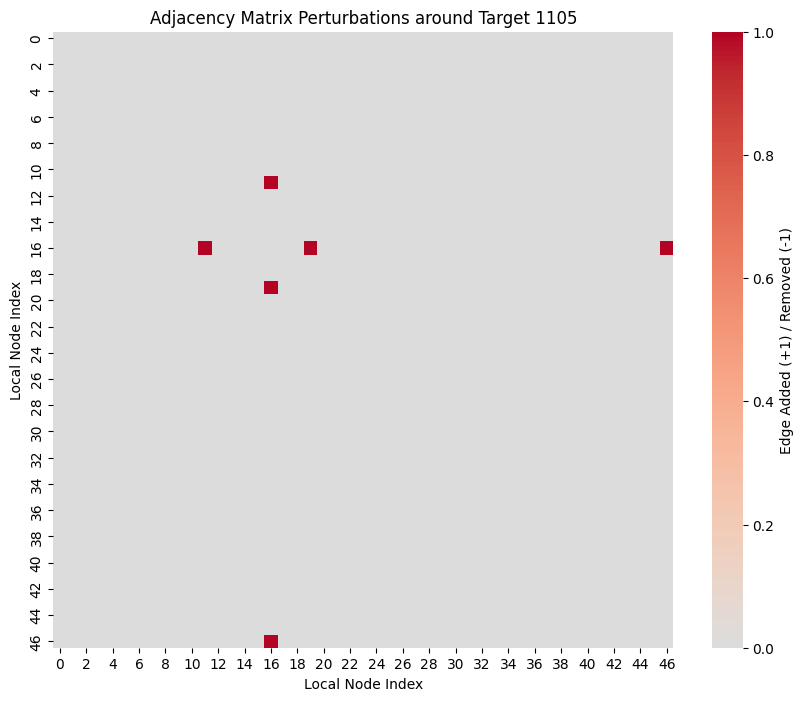

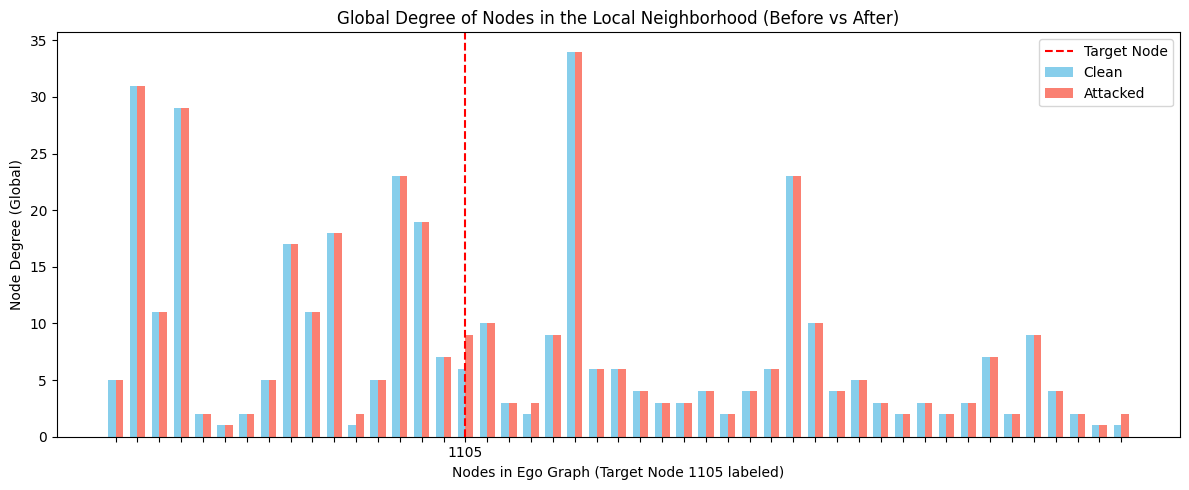

In [ ]:
import seaborn as sns
import numpy as np

# Get all nodes involved in both the clean and attacked ego networks
nodes_combined = list(set(ego_clean.nodes()) | set(ego_attacked.nodes()))

# 1. Adjacency Matrix Difference (Local Neighborhood Heatmap)
sub_adj_clean = nx.to_numpy_array(G_clean.subgraph(nodes_combined), nodelist=nodes_combined)
sub_adj_attacked = nx.to_numpy_array(G_attacked.subgraph(nodes_combined), nodelist=nodes_combined)
diff_adj = sub_adj_attacked - sub_adj_clean

plt.figure(figsize=(10, 8))
sns.heatmap(diff_adj, cmap="coolwarm", center=0, cbar_kws={'label': 'Edge Added (+1) / Removed (-1)'})
plt.title(f"Adjacency Matrix Perturbations around Target {target_node}")
plt.xlabel("Local Node Index")
plt.ylabel("Local Node Index")
plt.show()

# 2. Degree Comparison Bar Chart
degrees_clean = [G_clean.degree(n) for n in nodes_combined]
degrees_attacked = [G_attacked.degree(n) for n in nodes_combined]

plt.figure(figsize=(12, 5))
x = np.arange(len(nodes_combined))
width = 0.35

plt.bar(x - width/2, degrees_clean, width, label='Clean', color='skyblue')
plt.bar(x + width/2, degrees_attacked, width, label='Attacked', color='salmon')

# Highlight the target node's position
target_idx = nodes_combined.index(target_node)
plt.axvline(x=target_idx, color='red', linestyle='--', label='Target Node')

plt.ylabel('Node Degree (Global)')
plt.title('Global Degree of Nodes in the Local Neighborhood (Before vs After)')

# Only label the target node on the x-axis to avoid clutter
x_labels = [str(n) if n == target_node else "" for n in nodes_combined]
plt.xticks(x, x_labels)
plt.xlabel(f'Nodes in Ego Graph (Target Node {target_node} labeled)')
plt.legend()
plt.tight_layout()
plt.show()

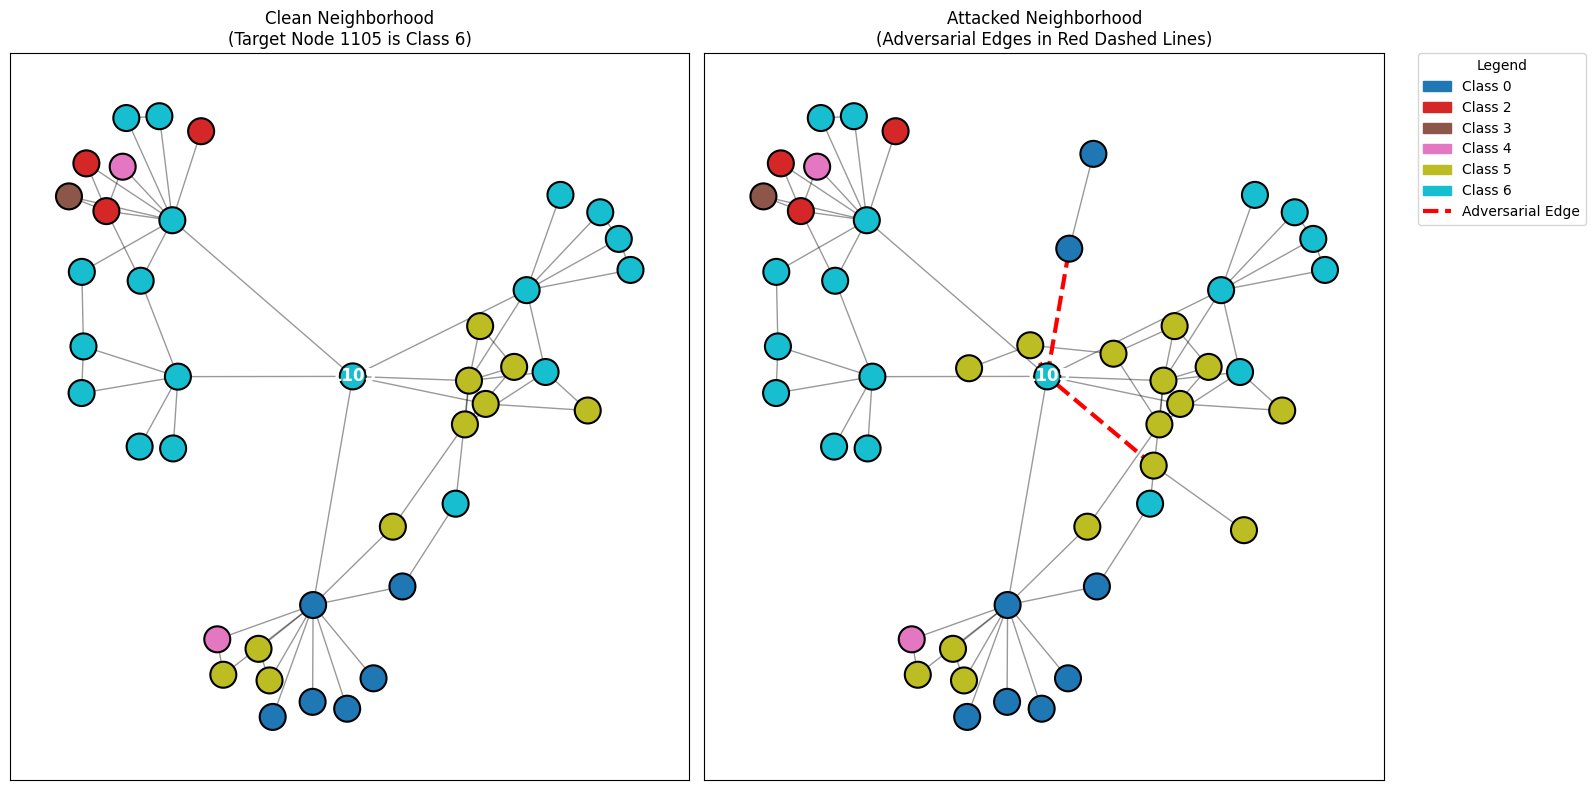

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

# We will use the ego_attacked and ego_clean networks from earlier
# and color them by their actual ground-truth classes.
neighborhood_nodes = list(ego_attacked.nodes())
neighborhood_labels = [labels[n] for n in neighborhood_nodes]
unique_labels = list(set(neighborhood_labels))

# Create a distinct color map for the classes
colors = plt.cm.get_cmap('tab10', max(unique_labels) + 1)
label_to_color = {lbl: colors(lbl) for lbl in unique_labels}

node_colors_clean = [label_to_color[labels[n]] for n in ego_clean.nodes()]
node_colors_attacked = [label_to_color[labels[n]] for n in ego_attacked.nodes()]

plt.figure(figsize=(16, 8))

# Calculate a fixed layout based on the attacked graph so nodes don't move between plots
pos = nx.spring_layout(ego_attacked, seed=42)

# --- 1. Clean Neighborhood Plot ---
plt.subplot(1, 2, 1)
# Draw nodes
nx.draw_networkx_nodes(ego_clean, pos, node_color=node_colors_clean, node_size=350, edgecolors='black', linewidths=1.5)
# Draw edges
nx.draw_networkx_edges(ego_clean, pos, alpha=0.4)
# Label only the target node to keep it clean
nx.draw_networkx_labels(ego_clean, pos, {target_node: str(target_node)}, font_color='white', font_weight='bold')
plt.title(f"Clean Neighborhood\n(Target Node {target_node} is Class {labels[target_node]})")

# --- 2. Attacked Neighborhood Plot ---
plt.subplot(1, 2, 2)
# Draw nodes
nx.draw_networkx_nodes(ego_attacked, pos, node_color=node_colors_attacked, node_size=350, edgecolors='black', linewidths=1.5)

# Split edges into original and adversarial for distinct styling
clean_edges = [e for e in ego_attacked.edges() if G_clean.has_edge(*e)]
nx.draw_networkx_edges(ego_attacked, pos, edgelist=clean_edges, alpha=0.4)

# Highlight adversarial edges
nx.draw_networkx_edges(ego_attacked, pos, edgelist=added_edges, edge_color='red', width=3, style='dashed')

# Label only the target node
nx.draw_networkx_labels(ego_attacked, pos, {target_node: str(target_node)}, font_color='white', font_weight='bold')
plt.title("Attacked Neighborhood\n(Adversarial Edges in Red Dashed Lines)")

# --- 3. Legend ---
legend_handles = [mpatches.Patch(color=label_to_color[l], label=f'Class {l}') for l in unique_labels]
# Add a special handle for the adversarial edge
legend_handles.append(plt.Line2D([0], [0], color='red', linewidth=3, linestyle='--', label='Adversarial Edge'))

plt.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.05, 1), title="Legend", borderaxespad=0.)

plt.tight_layout()
plt.show()

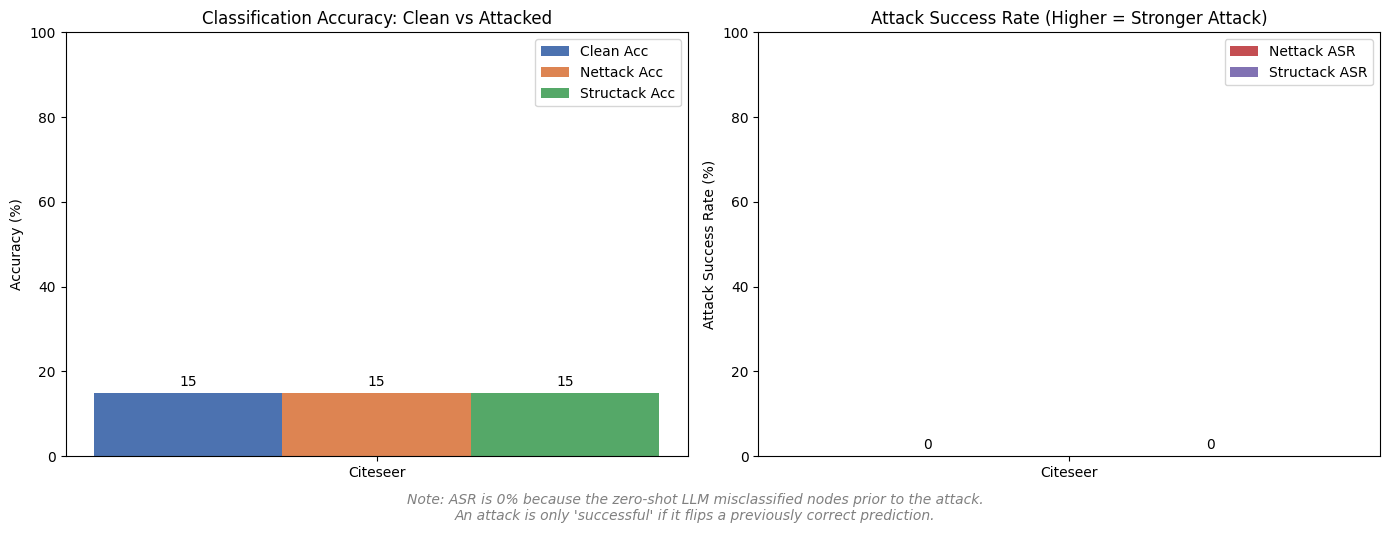

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Using the metrics gathered from the run_adversarial_pipeline output.
# (We manually define them here since they were scoped inside the function).

datasets = ['Citeseer']
clean_acc = [15.0]
nettack_acc = [15.0]
structack_acc = [15.0]

# Attack Success Rate (ASR)
nettack_asr = [0.0]
structack_asr = [0.0]

x = np.arange(len(datasets))  # the label locations
width = 0.2  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Accuracy Comparison ---
rects1 = ax1.bar(x - width, clean_acc, width, label='Clean Acc', color='#4C72B0')
rects2 = ax1.bar(x, nettack_acc, width, label='Nettack Acc', color='#DD8452')
rects3 = ax1.bar(x + width, structack_acc, width, label='Structack Acc', color='#55A868')

ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Classification Accuracy: Clean vs Attacked')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.set_ylim(0, 100)
ax1.legend()

# Add values on top of bars
ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)

# --- Plot 2: Attack Success Rate (ASR) ---
rects4 = ax2.bar(x - width/2, nettack_asr, width, label='Nettack ASR', color='#C44E52')
rects5 = ax2.bar(x + width/2, structack_asr, width, label='Structack ASR', color='#8172B3')

ax2.set_ylabel('Attack Success Rate (%)')
ax2.set_title('Attack Success Rate (Higher = Stronger Attack)')
ax2.set_xticks(x)
ax2.set_xticklabels(datasets)
ax2.set_ylim(0, 100)
ax2.legend()

# Add values on top of bars
ax2.bar_label(rects4, padding=3)
ax2.bar_label(rects5, padding=3)

# Add a helpful footnote
plt.figtext(0.5, -0.05, "Note: ASR is 0% because the zero-shot LLM misclassified nodes prior to the attack.\nAn attack is only 'successful' if it flips a previously correct prediction.", ha="center", fontsize=10, style='italic', color='gray')

plt.tight_layout()
plt.show()